Task 1: Data Preparation

Loading the Data

• Download the provided folder that contains the Devnagari digits dataset.

• Use the Python Imaging Library (PIL) to load and read the image files from the dataset.

• Convert the images into Numpy arrays and normalize them to a range of 0-1.

• use train folder for training and test for testing.

• Extract the corresponding labels for each image.

Hints:
• Ensure that the images are resized to a consistent shape (e.g., 28x28).

• Convert labels to one-hot encoded format for multi-class classification.

In [11]:
# import necessary libraries
import os
import numpy as np
from PIL import Image
from tensorflow.keras.utils import to_categorical

# define dataset paths
train_path = '/content/DevanagariHandwrittenDigitDataset/Train'  # train folder
test_path = '/content/DevanagariHandwrittenDigitDataset/Test'    # test folder

# define image size
img_size = (28, 28)  # consistent size for all images

# function to load images and labels from a folder
def load_data(data_path):
    images = []
    labels = []
    for label_folder in sorted(os.listdir(data_path)):
        class_folder_path = os.path.join(data_path, label_folder)
        if os.path.isdir(class_folder_path):
            # extract numeric label from folder name like 'digit_0' -> 0
            label = int(label_folder.split('_')[1])
            for image_file in os.listdir(class_folder_path):
                img_path = os.path.join(class_folder_path, image_file)
                img = Image.open(img_path).convert('L')  # convert to grayscale
                img = img.resize(img_size)                # resize to 28x28
                img_array = np.array(img) / 255.0        # normalize to 0-1
                images.append(img_array)
                labels.append(label)
    images = np.array(images)
    labels = np.array(labels)
    return images, labels

# load train and test data
X_train, y_train = load_data(train_path)
X_test, y_test = load_data(test_path)

# reshape images to (num_samples, 28*28) for FCN
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

# convert labels to one-hot encoding
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# print shapes to verify
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (17000, 784)
y_train shape: (17000, 10)
X_test shape: (3000, 784)
y_test shape: (3000, 10)


Task 2: Build the FCN Model

Model Architecture

• Create a Sequential model using Keras.

• Add 3 hidden layers with the following number of neurons:
– 1st hidden layer: 64 neurons
– 2nd hidden layer: 128 neurons
– 3rd hidden layer: 256 neurons

• Use sigmoid activation functions for all hidden layers.

• Add an output layer with 10 units with softmax (since Devnagari digits have 10 classes) and a
softmax activation function.

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# define the FCN model
model = Sequential()

# 1st hidden layer: 64 neurons, sigmoid activation
model.add(Dense(64, activation='sigmoid', input_shape=(28*28,)))

# 2nd hidden layer: 128 neurons, sigmoid activation
model.add(Dense(128, activation='sigmoid'))

# 3rd hidden layer: 256 neurons, sigmoid activation
model.add(Dense(256, activation='sigmoid'))

# output layer: 10 neurons (classes), softmax activation
model.add(Dense(10, activation='softmax'))

# compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# print model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

Task 3: Compile the Model

Model Compilation

• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy),
and evaluation metric (e.g., accuracy).

In [14]:
# print model summary to verify architecture
model.summary()

# train the model
history = model.fit(
    X_train, y_train,       # training data
    validation_split=0.1,   # use 10% of training data for validation
    epochs=20,              # number of epochs (adjust as needed)
    batch_size=32,          # batch size
    verbose=1               # shows training progress
)

# evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
479/479 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7411 - loss: 0.8417 - val_accuracy: 0.0000e+00 - val_loss: 8.7328
Epoch 2/20
479/479 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9424 - loss: 0.1983 - val_accuracy: 0.0000e+00 - val_loss: 9.4332
Epoch 3/20
479/479 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9637 - loss: 0.1227 - val_accuracy: 0.0000e+00 - val_loss: 9.5335
Epoch 4/20
479/479 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9757 - loss: 0.0844 - val_accuracy: 0.0000e+00 - val_loss: 10.1411
Epoch 5/20
479/479 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9831 - loss: 0.0617 - val_accuracy: 0.0000e+00 - val_loss: 10.2371
Epoch 6/20
479/479 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9869 - loss: 0.0469 - val_accuracy: 0.0000e+00 - val_loss: 10.8998
Epoch 7/20
479/479 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9907 - loss: 0.0349 - val_accuracy: 0.0000e+00 - val_loss: 10.5695
Epoch 8/20
479/479 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9919 -

Task 4: Train the Model

Model Training

• Use the model.fit() function to train the model. Set the batch size to 128 and the number ofepochs to 20.

• Use validation split (validation split=0.2) to monitor the model’s performance on validation data.

• Optionally, use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model
and avoiding overfitting.

In [15]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# define callbacks
checkpoint = ModelCheckpoint(
    'best_model.h5',          # file to save the best model
    monitor='val_loss',       # monitor validation loss
    save_best_only=True,      # save only the best model
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',       # stop if validation loss stops improving
    patience=5,               # wait 5 epochs before stopping
    restore_best_weights=True,
    verbose=1
)

# train the model
history = model.fit(
    X_train, y_train,
    batch_size=128,           # as specified
    epochs=20,                # as specified
    validation_split=0.2,     # use 20% of training data for validation
    callbacks=[checkpoint, early_stop],
    verbose=1
)

# evaluate on test data
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")

Epoch 1/20
101/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9996 - loss: 0.0017
Epoch 1: val_loss improved from None to 6.17382, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9996 - loss: 0.0017 - val_accuracy: 0.5000 - val_loss: 6.1738
Epoch 2/20
104/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9999 - loss: 8.1522e-04
Epoch 2: val_loss did not improve from 6.17382
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9999 - loss: 8.1824e-04 - val_accuracy: 0.5000 - val_loss: 6.1833
Epoch 3/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 4.8200e-04
Epoch 3: val_loss improved from 6.17382 to 6.14792, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9999 - loss: 6.9870e-04 - val_accuracy: 0.5000 - val_loss: 6.1479
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9999 - loss: 7.7461e-04
Epoch 4: val_loss did not improve from 6.14792
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9999 - loss: 6.2310e-04 - val_accuracy: 0.5000 - val_loss: 6.2079
Epoch 5/20
 99/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9999 - loss: 6.5032e-04
Epoch 5: val_loss did not improve from 6.14792
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9999 - loss: 6.0599e-04 - val_accuracy: 0.5000 - val_loss: 6.2225
Epoch 6/20
101/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9999 - loss: 5.8762e-04
Epoch 6: val_loss did not improve from 6.14792
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9999 - loss: 5.6095e-04 - val_accuracy: 0.5000 - val_loss: 6.2444
Epoch 7/20
105/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - ac

Task 5: Evaluate the Model

Model Evaluation

• After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss.

In [16]:
# evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

# print the results
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8830 - loss: 1.3206
Test Loss: 1.3206
Test Accuracy: 88.30%


Task 6: Save and Load the Model


• Save the trained model to an .h5 file using model.save().

• Load the saved model and re-evaluate its performance on the test set.

In [17]:
from tensorflow.keras.models import load_model

# --- Save the trained model ---
model.save('devnagari_fcn_model.h5')   # saves the full model (architecture + weights + optimizer)
print("Model saved to 'devnagari_fcn_model.h5'")

# --- Load the saved model ---
loaded_model = load_model('devnagari_fcn_model.h5')
print("Model loaded successfully!")

# --- Re-evaluate the loaded model on the test set ---
test_loss, test_accuracy = loaded_model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss (loaded model): {test_loss:.4f}")
print(f"Test Accuracy (loaded model): {test_accuracy*100:.2f}%")

Model saved to 'devnagari_fcn_model.h5'
Model loaded successfully!
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8830 - loss: 1.3206
Test Loss (loaded model): 1.3206
Test Accuracy (loaded model): 88.30%


Task 7: Predictions

Making Predictions

• Use model.predict() to make predictions on test images.

• Convert the model’s predicted probabilities to digit labels using np.argmax().

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
First 10 predictions vs true labels:
Predicted: 0, True: 0
Predicted: 0, True: 0
Predicted: 0, True: 0
Predicted: 0, True: 0
Predicted: 0, True: 0
Predicted: 0, True: 0
Predicted: 0, True: 0
Predicted: 0, True: 0
Predicted: 0, True: 0
Predicted: 0, True: 0


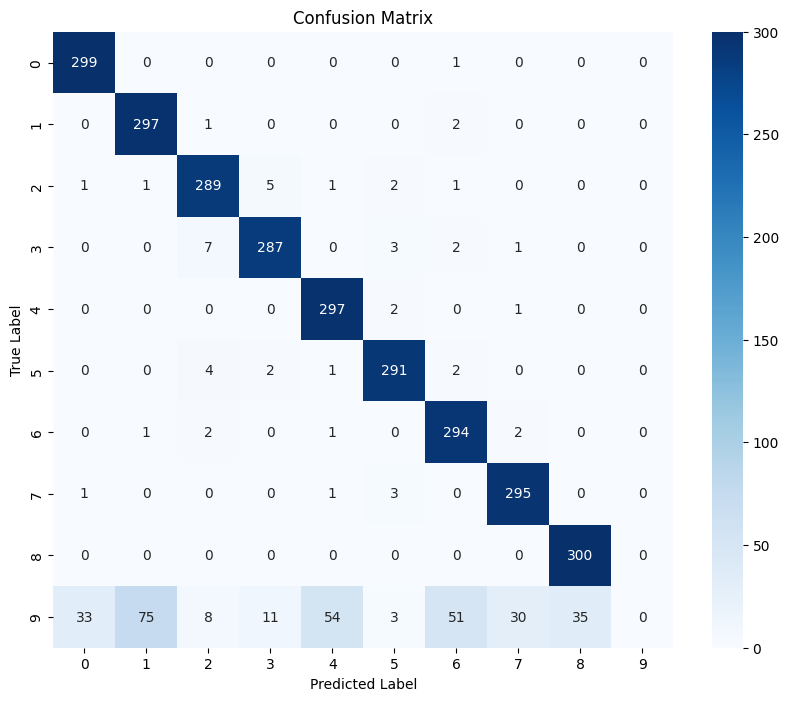

Classification Report:

              precision    recall  f1-score   support

           0     0.8952    0.9967    0.9432       300
           1     0.7941    0.9900    0.8813       300
           2     0.9293    0.9633    0.9460       300
           3     0.9410    0.9567    0.9488       300
           4     0.8366    0.9900    0.9069       300
           5     0.9572    0.9700    0.9636       300
           6     0.8329    0.9800    0.9005       300
           7     0.8967    0.9833    0.9380       300
           8     0.8955    1.0000    0.9449       300
           9     0.0000    0.0000    0.0000       300

    accuracy                         0.8830      3000
   macro avg     0.7978    0.8830    0.8373      3000
weighted avg     0.7978    0.8830    0.8373      3000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [20]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# predictions on test data
y_pred_prob = model.predict(X_test)              # predicted probabilities
y_pred_labels = np.argmax(y_pred_prob, axis=1)  # convert to digit labels
y_true_labels = np.argmax(y_test, axis=1)       # convert one-hot to digit labels

#Display first 10 predictions
print("First 10 predictions vs true labels:")
for i in range(10):
    print(f"Predicted: {y_pred_labels[i]}, True: {y_true_labels[i]}")

# Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

#Classification Report
print("Classification Report:\n")
print(classification_report(y_true_labels, y_pred_labels, digits=4))